In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
torch.set_default_dtype(torch.float64)

from matplotlib import pyplot as plt

from scipy.special import logit

In [3]:
import sys
import os
sys.path.append(os.path.abspath('/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation'))

from src.config import DataConfig, AlgorithmConfig
from src.objectives import LipschitzSelection, SmoothSelection, HardSelection
from src.dgp import IsotropicGaussian
from src.asymptotics import MacroscopicStateEvolution
from src.algorithms import SelfTrainedGradientDescent
from src.callbacks import TestEvaluatorCallback
from src.utils import plot_autograd_dag

from scripts.runner import MonteCarloExperiment

In [51]:
import textwrap

def plot_macroscopic_evolution(callback, se, algorithm_cfg, extra_text=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # --- Plot 1: Errors ---
    axes[0, 0].plot(callback.history_["population_error"], label="GD")
    axes[0, 0].plot(torch.tensor(se.error).detach().numpy(), label="SE")
    axes[0, 0].set_title(r"Error Evolution $\mathcal{E}_t$")

    # --- Plot 2: Unlabeled Usage ---
    axes[0, 1].plot(callback.history_["unl_usage"], label="GD")
    axes[0, 1].plot(torch.tensor(se.selection_rate).detach().numpy(), label="SE")
    axes[0, 1].set_title(r"Pseudo-Labeling rate Evolution $A_t$")

    # --- Plot 3: Bias Term ---
    axes[0, 2].plot(callback.history_["bias_term"], label="GD")
    axes[0, 2].plot(torch.tensor(se.bias).detach().numpy(), label="SE")
    axes[0, 2].set_title(rf"Bias Evolution $b^t$ (Include Bias = {algorithm_cfg.include_bias})")

    # --- Plot 4: Weight-Signal Alignment ---
    axes[1, 0].plot(callback.history_["weight_signal_alignment"], label="GD")
    axes[1, 0].plot(torch.tensor(se.weight_signal_alignments).detach().numpy(), label="SE")
    axes[1, 0].set_title(r"Weight-Signal Alignm. Evolution $m^t$")

    # --- Plot 5: Label-PseudoResidual Alignment ---
    axes[1, 1].plot(callback.history_["train_label_residual_alignment"], label="GD")
    axes[1, 1].plot(torch.tensor(se.label_residual_alignments).detach().numpy(), label="SE")
    axes[1, 1].set_title(r"Label-PseudoResidual Alignm. Evolution $\chi^t$")

    # --- Plot 6: Mean PseudoResidual ---
    axes[1, 2].plot(callback.history_["train_mean_residual"], label="GD")
    axes[1, 2].plot(torch.tensor(se.mean_residual).detach().numpy(), label="SE")
    axes[1, 2].set_title(r"Mean PseudoResidual Evolution $\zeta^t$")

    for ax in axes.flatten():
        ax.set_xlabel("Iteration")
        ax.legend()
        ax.grid(which="major", color="#999999", linestyle="-", linewidth=0.8)
        ax.grid(which="minor", color="#999999", linestyle=":", linewidth=0.5)
        ax.minorticks_on()

    fig.suptitle("Evolution of Macroscopic quantities", fontsize=20)

    # --- Parameter formatting similar to plot_experiment() ---
    latex_map = {
        "gamma": r"$\gamma$",
        "penalty_param": r"$\lambda$",
        "lambd": r"$\lambda$",
        "margin_threshold": r"$\kappa$",
        "kappa": r"$\kappa$",
        "step_size": r"$\eta$",
        "eta": r"$\eta$",
        "pseudo_label_param": r"$\alpha$",
        "alpha": r"$\alpha$",
        "ramp_start": r"$T_0$",
        "ramp_end": r"$T_1$",
        "n_iterations": r"$T$",
        "include_bias": "Include\xa0bias",
        "loss_function": "Loss\xa0Function",
        "penalty_function": "Penalty\xa0Function",
    }

    def format_val(val):
        if isinstance(val, (list, np.ndarray, torch.Tensor)):
            return "Schedule"
        if isinstance(val, (float, np.floating)):
            return f"{val:.3f}"
        if isinstance(val, (int, np.integer)):
            return str(val)
        if isinstance(val, bool):
            return "True" if val else "False"
        if hasattr(val, "__class__") and type(val).__module__ != "builtins":
            return val.__class__.__name__
        return str(val)

    param_parts = []
    for k, v in algorithm_cfg.__dict__.items():
        # Filter out parameters you do not want to display in the footnote
        if k in {"ramp_start", "ramp_end", "pseudo_label_param_schedule_"}:
            continue
        if k == "selection_function":
            val_text = getattr(v, "__class__", None).__name__ if getattr(v, "__class__", None) else str(v)
            param_parts.append(rf"{k}={val_text}")
        else:
            sym_k = latex_map.get(k, k)
            val_str = format_val(v)
            param_parts.append(rf"{sym_k}={val_str}")

    fixed_str = ", ".join(param_parts)
    wrapped_fixed = textwrap.fill(f"Parameters: {fixed_str}", width=100)

    box_text = wrapped_fixed
    if extra_text:
        wrapped_extra = textwrap.fill(f"Note: {extra_text}", width=100)
        box_text += f"\n{wrapped_extra}"

    fig.subplots_adjust(bottom=0.25)
    fig.text(
        0.5,
        0.0,
        box_text,
        ha="center",
        va="bottom",
        fontsize=16,
        bbox=dict(
            boxstyle="round,pad=0.6",
            facecolor="#f8f9fa",
            edgecolor="#dee2e6",
            alpha=0.9,
        ),
    )

    plt.tight_layout(rect=(0, 0.10, 1, 1))
    plt.show()

## With Bias

In [57]:
# --- Experiment Seed ---

seed = 42

# --- Model Configuration ---

delta = 2.0

se_data_cfg = DataConfig(
    scale=1.0,
    label_prior=0.5,
    supervision_ratio=0.1,
    data_to_dimension_ratio=delta,
    signal_law=lambda: torch.randn(1).item()
)

# --- Data Configuration ---

d = 5000
N = int(delta * d)
K = 20000

se_dgp = IsotropicGaussian(
    cfg=se_data_cfg, 
    n_train=N, 
    n_test=1, 
    dimensions=d, 
    seed=42
)

# --- Algorithm Configuration ---

T = 100
epsilon = 0.03
hard_forward = False

se_algo_cfg = AlgorithmConfig(
    n_iterations=T,
    margin_threshold=logit(0.8),
    step_size=0.1,
    penalty_param=0.1,
    pseudo_label_param=5.0,
    ramp_start=0,
    ramp_end=0,
    include_bias=True,
    selection_function=SmoothSelection(epsilon, hard_forward)
)

In [58]:
# --- Sample Data ---

se_X_lab, se_Y_lab, se_X_unl, se_Y_unl, \
    se_X_test, se_Y_test = se_dgp.sample(stratified=False)

# --- Initializing Callback ---

se_callback = TestEvaluatorCallback(
    X_lab=se_X_lab,
    Y_lab=se_Y_lab,
    X_unl=se_X_unl, 
    Y_unl=se_Y_unl,
    X_test=se_X_test, 
    Y_test=se_Y_test,
    mu=se_dgp._mu,
    sigma=se_data_cfg.scale,
    p=se_data_cfg.label_prior,
    metrics={
        "population_error", 
        "unl_usage", 
        "weight_signal_alignment", 
        "weight_vector_norm", 
        "bias_term",
        "train_label_residual_alignment",
        "train_mean_residual"
    }
)

In [59]:
# --- Running Algorithm ---

se_algo = SelfTrainedGradientDescent(
    cfg=se_algo_cfg, 
    callback=se_callback
)

torch.manual_seed(seed)
se_algo.fit(se_X_lab, se_Y_lab, se_X_unl)

In [60]:
# --- Running State Evolution ---

se = MacroscopicStateEvolution(
    data_cfg=se_data_cfg,
    algo_cfg=se_algo_cfg,
    K=K
)

torch.manual_seed(seed)
se.compute_trajectory()

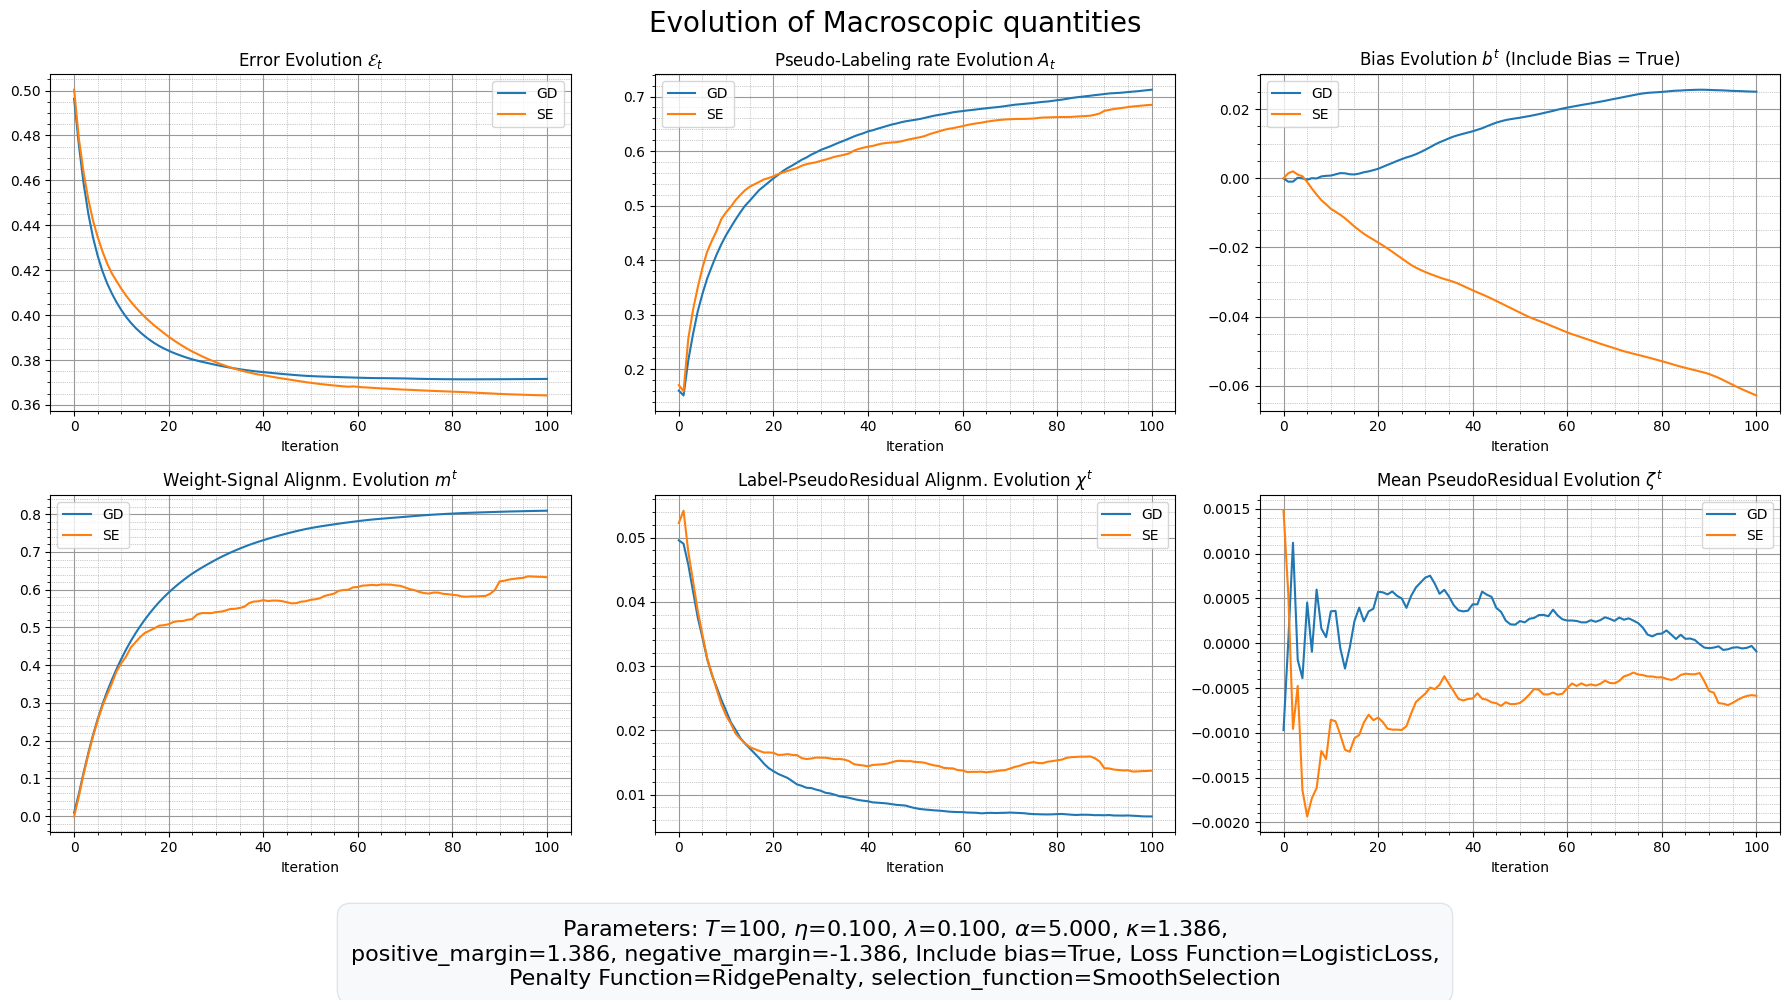

In [61]:
plot_macroscopic_evolution(se_callback, se, se_algo_cfg)

## Without Bias

In [62]:
# --- Experiment Seed ---

seed = 42

# --- Model Configuration ---

delta = 2.0

se_data_cfg = DataConfig(
    scale=1.0,
    label_prior=0.5,
    supervision_ratio=0.1,
    data_to_dimension_ratio=delta,
    signal_law=lambda: torch.randn(1).item()
)

# --- Data Configuration ---

d = 5000
N = int(delta * d)
K = 20000

se_dgp = IsotropicGaussian(
    cfg=se_data_cfg, 
    n_train=N, 
    n_test=1, 
    dimensions=d, 
    seed=42
)

# --- Algorithm Configuration ---

T = 100
epsilon = 0.03
hard_forward = False

se_algo_cfg = AlgorithmConfig(
    n_iterations=T,
    margin_threshold=logit(0.8),
    step_size=0.1,
    penalty_param=0.1,
    pseudo_label_param=5.0,
    ramp_start=0,
    ramp_end=0,
    include_bias=False,
    selection_function=SmoothSelection(epsilon, hard_forward)
)

In [63]:
# --- Sample Data ---

se_X_lab, se_Y_lab, se_X_unl, se_Y_unl, \
    se_X_test, se_Y_test = se_dgp.sample(stratified=False)

# --- Initializing Callback ---

se_callback = TestEvaluatorCallback(
    X_lab=se_X_lab,
    Y_lab=se_Y_lab,
    X_unl=se_X_unl, 
    Y_unl=se_Y_unl,
    X_test=se_X_test, 
    Y_test=se_Y_test,
    mu=se_dgp._mu,
    sigma=se_data_cfg.scale,
    p=se_data_cfg.label_prior,
    metrics={
        "population_error", 
        "unl_usage", 
        "weight_signal_alignment", 
        "weight_vector_norm", 
        "bias_term",
        "train_label_residual_alignment",
        "train_mean_residual"
    }
)

In [64]:
# --- Running Algorithm ---

se_algo = SelfTrainedGradientDescent(
    cfg=se_algo_cfg, 
    callback=se_callback
)

torch.manual_seed(seed)
se_algo.fit(se_X_lab, se_Y_lab, se_X_unl)

In [65]:
# --- Running State Evolution ---

se = MacroscopicStateEvolution(
    data_cfg=se_data_cfg,
    algo_cfg=se_algo_cfg,
    K=K
)

torch.manual_seed(seed)
se.compute_trajectory()

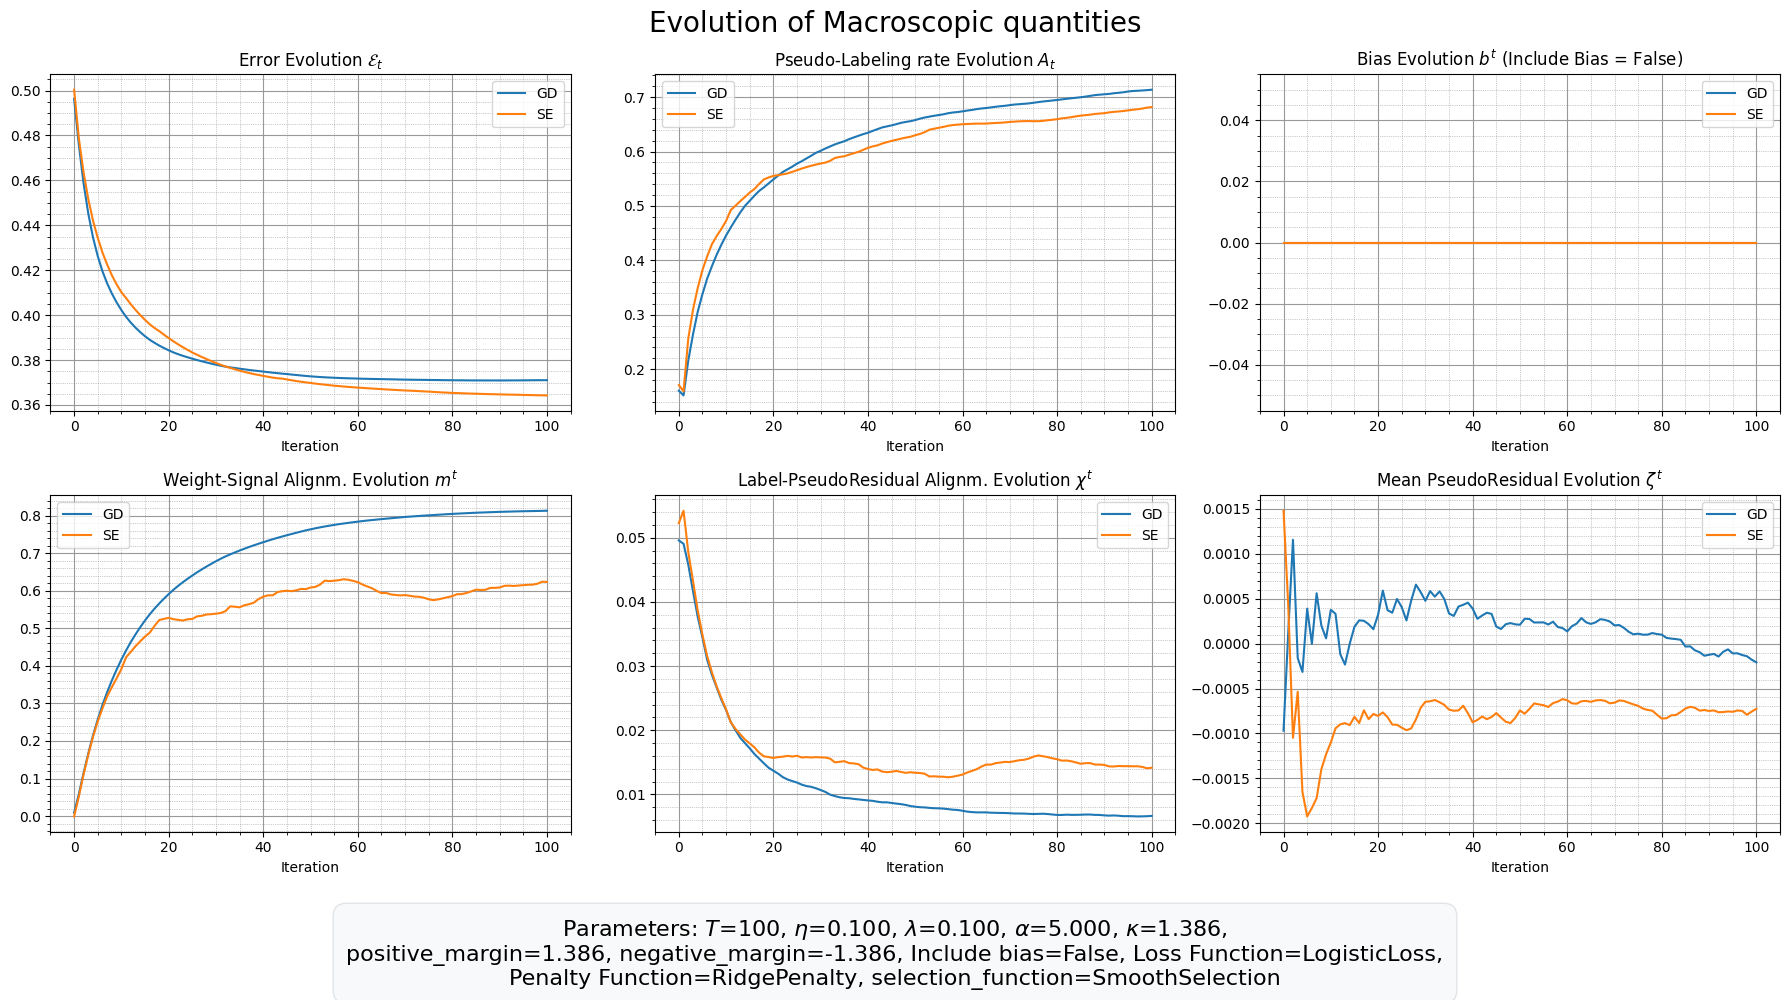

In [66]:
plot_macroscopic_evolution(se_callback, se, se_algo_cfg)

## Asymmetric Labels - With Bias

In [68]:
# --- Experiment Seed ---

seed = 42

# --- Model Configuration ---

delta = 2.0

se_data_cfg = DataConfig(
    scale=1.0,
    label_prior=0.2,
    supervision_ratio=0.1,
    data_to_dimension_ratio=delta,
    signal_law=lambda: torch.randn(1).item()
)

# --- Data Configuration ---

d = 5000
N = int(delta * d)
K = 20000

se_dgp = IsotropicGaussian(
    cfg=se_data_cfg, 
    n_train=N, 
    n_test=1, 
    dimensions=d, 
    seed=42
)

# --- Algorithm Configuration ---

T = 100
epsilon = 0.03
hard_forward = False

se_algo_cfg = AlgorithmConfig(
    n_iterations=T,
    margin_threshold=logit(0.8),
    step_size=0.1,
    penalty_param=0.1,
    pseudo_label_param=5.0,
    ramp_start=0,
    ramp_end=0,
    include_bias=True,
    selection_function=SmoothSelection(epsilon, hard_forward)
)

In [69]:
# --- Sample Data ---

se_X_lab, se_Y_lab, se_X_unl, se_Y_unl, \
    se_X_test, se_Y_test = se_dgp.sample(stratified=False)

# --- Initializing Callback ---

se_callback = TestEvaluatorCallback(
    X_lab=se_X_lab,
    Y_lab=se_Y_lab,
    X_unl=se_X_unl, 
    Y_unl=se_Y_unl,
    X_test=se_X_test, 
    Y_test=se_Y_test,
    mu=se_dgp._mu,
    sigma=se_data_cfg.scale,
    p=se_data_cfg.label_prior,
    metrics={
        "population_error", 
        "unl_usage", 
        "weight_signal_alignment", 
        "weight_vector_norm", 
        "bias_term",
        "train_label_residual_alignment",
        "train_mean_residual"
    }
)

In [70]:
# --- Running Algorithm ---

se_algo = SelfTrainedGradientDescent(
    cfg=se_algo_cfg, 
    callback=se_callback
)

torch.manual_seed(seed)
se_algo.fit(se_X_lab, se_Y_lab, se_X_unl)

In [71]:
# --- Running State Evolution ---

se = MacroscopicStateEvolution(
    data_cfg=se_data_cfg,
    algo_cfg=se_algo_cfg,
    K=K
)

torch.manual_seed(seed)
se.compute_trajectory()

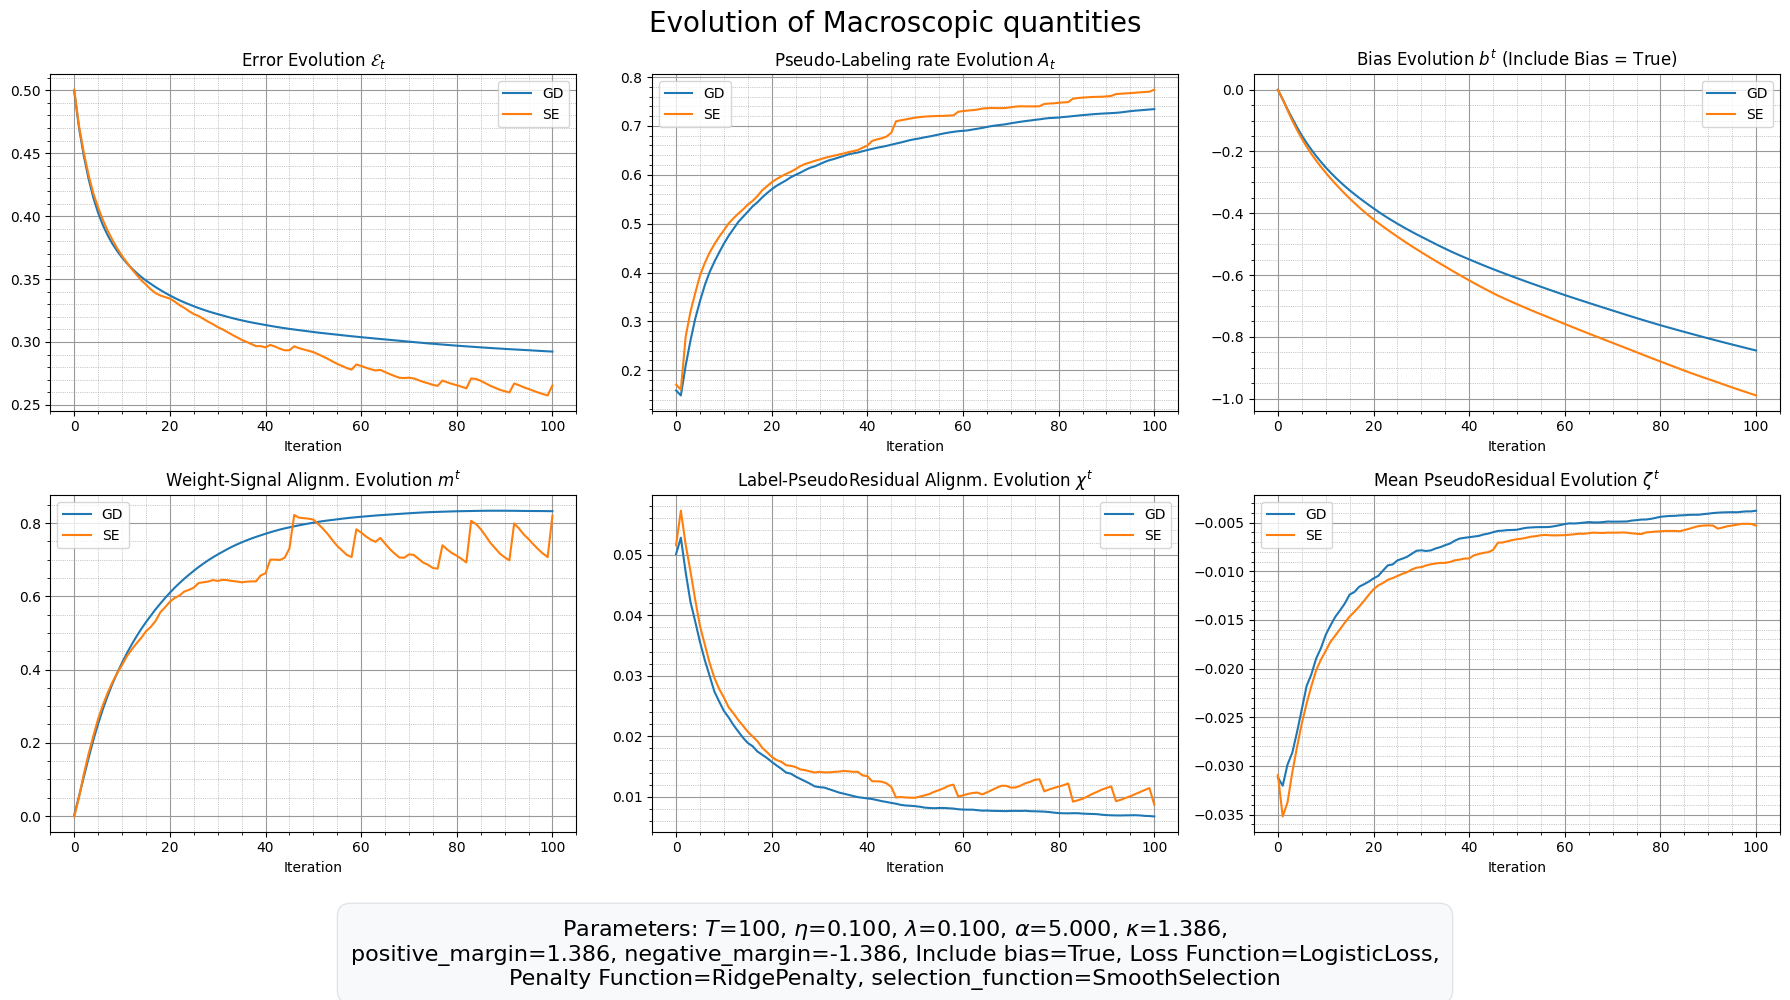

In [72]:
plot_macroscopic_evolution(se_callback, se, se_algo_cfg)

## Asymmetric Labels - Without Bias

In [73]:
# --- Experiment Seed ---

seed = 42

# --- Model Configuration ---

delta = 2.0

se_data_cfg = DataConfig(
    scale=1.0,
    label_prior=0.2,
    supervision_ratio=0.1,
    data_to_dimension_ratio=delta,
    signal_law=lambda: torch.randn(1).item()
)

# --- Data Configuration ---

d = 5000
N = int(delta * d)
K = 20000

se_dgp = IsotropicGaussian(
    cfg=se_data_cfg, 
    n_train=N, 
    n_test=1, 
    dimensions=d, 
    seed=42
)

# --- Algorithm Configuration ---

T = 100
epsilon = 0.03
hard_forward = False

se_algo_cfg = AlgorithmConfig(
    n_iterations=T,
    margin_threshold=logit(0.8),
    step_size=0.1,
    penalty_param=0.1,
    pseudo_label_param=5.0,
    ramp_start=0,
    ramp_end=0,
    include_bias=False,
    selection_function=SmoothSelection(epsilon, hard_forward)
)

In [74]:
# --- Sample Data ---

se_X_lab, se_Y_lab, se_X_unl, se_Y_unl, \
    se_X_test, se_Y_test = se_dgp.sample(stratified=False)

# --- Initializing Callback ---

se_callback = TestEvaluatorCallback(
    X_lab=se_X_lab,
    Y_lab=se_Y_lab,
    X_unl=se_X_unl, 
    Y_unl=se_Y_unl,
    X_test=se_X_test, 
    Y_test=se_Y_test,
    mu=se_dgp._mu,
    sigma=se_data_cfg.scale,
    p=se_data_cfg.label_prior,
    metrics={
        "population_error", 
        "unl_usage", 
        "weight_signal_alignment", 
        "weight_vector_norm", 
        "bias_term",
        "train_label_residual_alignment",
        "train_mean_residual"
    }
)

In [75]:
# --- Running Algorithm ---

se_algo = SelfTrainedGradientDescent(
    cfg=se_algo_cfg, 
    callback=se_callback
)

torch.manual_seed(seed)
se_algo.fit(se_X_lab, se_Y_lab, se_X_unl)

In [76]:
# --- Running State Evolution ---

se = MacroscopicStateEvolution(
    data_cfg=se_data_cfg,
    algo_cfg=se_algo_cfg,
    K=K
)

torch.manual_seed(seed)
se.compute_trajectory()

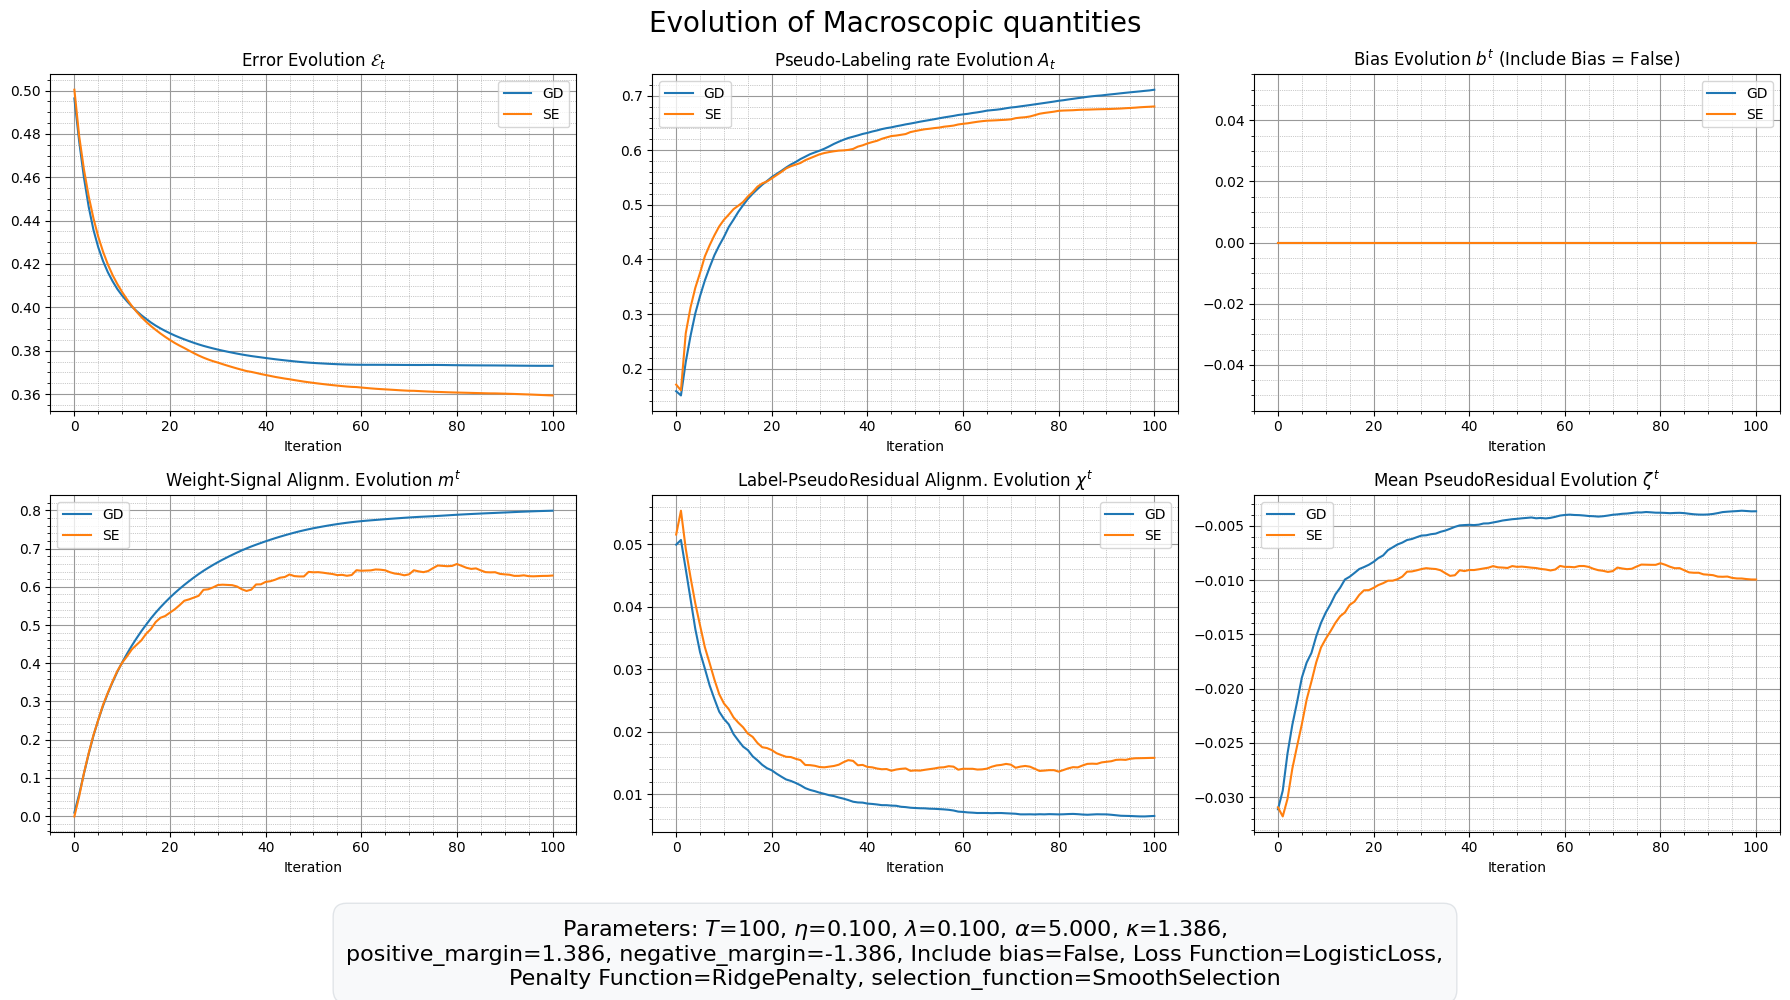

In [77]:
plot_macroscopic_evolution(se_callback, se, se_algo_cfg)